In [101]:
import pandas as pd
import numpy as np
import seaborn as sns
import tensorflow as tf

EXPLORING TENSORS

In [102]:
## Creating tensorflow variables - like container holding tensor (immutable) you can change
# usually infers datatype
# access tensor using var1.value()
var1 = tf.Variable(120)
var2 = tf.Variable(["hello"], tf.string)
var3 = tf.Variable([['bonjour', 'ciao'], ['salve', 'hola']])
var3

<tf.Variable 'Variable:0' shape=(2, 2) dtype=string, numpy=
array([[b'bonjour', b'ciao'],
       [b'salve', b'hola']], dtype=object)>

In [103]:
## Ranks of tensors
print(tf.rank(var1))
print(tf.rank(var2))
print(tf.rank(var3))


tf.Tensor(0, shape=(), dtype=int32)
tf.Tensor(1, shape=(), dtype=int32)
tf.Tensor(2, shape=(), dtype=int32)


In [104]:
## Shape of tensors
print(var2.shape)
print(var2)

# reshape a tensor (not variable)
tensor1 = tf.ones([1,2,3])
print(tensor1)
tensor1_reshaped1 = tf.reshape(tensor1, [2,3,1])
print(tensor1_reshaped1)
tensor1_reshaped2 = tf.reshape(tensor1_reshaped, [3, -1]) # -1 infers dimension (2 here)
print(tensor1_reshaped2)

(1,)
<tf.Variable 'Variable:0' shape=(1,) dtype=string, numpy=array([b'hello'], dtype=object)>
tf.Tensor(
[[[1. 1. 1.]
  [1. 1. 1.]]], shape=(1, 2, 3), dtype=float32)
tf.Tensor(
[[[1.]
  [1.]
  [1.]]

 [[1.]
  [1.]
  [1.]]], shape=(2, 3, 1), dtype=float32)
tf.Tensor(
[[1. 1.]
 [1. 1.]
 [1. 1.]], shape=(3, 2), dtype=float32)


MODELING

In [105]:
## Titanic dataset
df = pd.read_csv("../portfolio_datasets/titanic_dataset.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


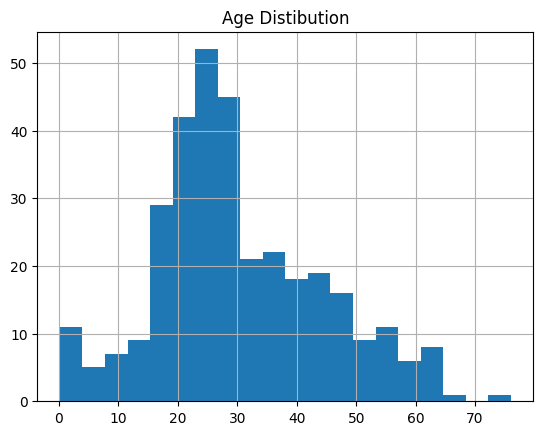

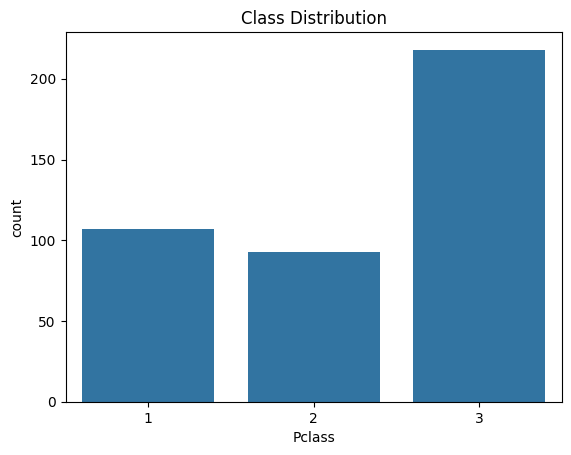

Pclass       0
Sex          0
Age         65
SibSp        0
Parch        0
Fare         1
Embarked     0
dtype: int64
Pclass       0
Sex          0
Age         21
SibSp        0
Parch        0
Fare         0
Embarked     0
dtype: int64


In [106]:
## Processing 

import sklearn
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import tensorflow.compat.v2.feature_column as fc

# Visualize some distributions
df.Age.hist(bins=20)
plt.title("Age Distibution")
plt.show()
sns.countplot(data=df, x='Pclass', order=sorted(df['Pclass'].unique()))
plt.title("Class Distribution")
plt.show()

# Clean
df = df.drop(columns=['Name', 'PassengerId', 'Ticket', 'Cabin'])

# Split dataset
X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12345)

# One hot encode & fill NAs

print(X_train.isnull().sum())
print(X_test.isnull().sum())

X_train['Fare'] = X_train['Fare'].fillna(X_train['Fare'].mean()) 

age_mean = X_train['Age'].mean()  
X_train['Age'] = X_train['Age'].fillna(age_mean) 
X_test['Age'] = X_test['Age'].fillna(age_mean)

CATEGORICAL_COLUMNS = ['Pclass', 'Sex', 'Embarked']

# One-hot encode categorical columns
X_train = pd.get_dummies(X_train, columns=CATEGORICAL_COLUMNS)
X_test = pd.get_dummies(X_test, columns=CATEGORICAL_COLUMNS)

# make sure train and test have the same columns
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [107]:
## Classification using estimators API (for 2.o)

# def make_input_fn(data_df, label_df, num_epochs=10, shuffle=True, batch_size=32):
#     def input_function():
#         ds = tf.data.Dataset.from_tensor_slices((dict(data_df), label_df))
#         if shuffle:
#             ds = ds.shuffle(buffer_size=1000)
#         ds = ds.batch(batch_size).repeat(num_epochs)
#         return ds
#     return input_function

# train_input_fn = make_input_fn(X_train, y_train, num_epochs=10, shuffle=True)
# eval_input_fn = make_input_fn(X_test, y_test, num_epochs=1, shuffle=False)

# example = tf.estimator.DNNclassifier(feature_columns=feature_columns, hidden_units=[32,16], n_classes=2)

# example.train(input_fn=train_input_fn)

# example_results = estimator.evaluate(input_fn=eval_input_fn)


## Classification using keras
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix


model = keras.Sequential([
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=10) #default batch 32
pred_raw = model.predict(X_test)
pred = (pred_raw > 0.5).astype(int)

def eval_metrics(actual, predictions):
    conf_matrix = confusion_matrix(actual, predictions)
    tn, fp, fn, tp = conf_matrix.ravel()

    accuracy = accuracy_score(actual, predictions)
    precision = precision_score(actual, predictions)
    sensitivity = recall_score(actual, predictions)  # same as recall
    specificity = tn / (tn + fp)
    f1 = f1_score(actual, predictions)

    print(f"{conf_matrix}\n")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Sensitivity: {sensitivity:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print(f"F1 Score: {f1:.4f}")

eval_metrics(y_test, pred)

Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6467 - loss: 0.9670  
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6527 - loss: 0.7184  
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6766 - loss: 0.6327 
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7006 - loss: 0.5557 
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6976 - loss: 0.5349 
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7216 - loss: 0.5066 
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7635 - loss: 0.4910 
Epoch 8/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8084 - loss: 0.4779 
Epoch 9/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7395 - loss: 0.4617  
Epoch 10/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8353 - loss: 0.4588 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
[[58  1]
 [17  8]]

Accuracy: 0.7857
Precision: 0.8889
Sensitivity: 0.3200
Specificity: 0.9831
F1 Score: 0.4